In [ ]:
import pandas as pd
import numpy as np
import re
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from sentence_transformers import SentenceTransformer
from umap import UMAP
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import seaborn as sns
from matplotlib.ticker import LogLocator, FuncFormatter

In [ ]:
moldova_df = pd.read_csv('..dataset/moldova.csv')

## Topic labeling

In [ ]:
moldova_df = moldova_df.drop_duplicates(subset='translatedContentText')
moldova_df = moldova_df[~moldova_df['is_retweet']]

def clean_for_bertopic(text):
    if pd.isnull(text):
        return ''
    
    text = re.sub(r'@\w+', '', text)                      # Remove mentions
    text = re.sub(r'#\w+', '', text)                      # Remove hashtag symbol, keep word
    text = re.sub(r'http\S+|www.\S+', '', text)           # Remove URLs
    text = re.sub(r'[^\x00-\x7F]+', '', text)             # Remove non-ASCII (emojis, signs)
    text = re.sub(r'\s+', ' ', text).strip()              # Normalize whitespace
    return text

moldova_df['bertopicText'] = moldova_df['translatedContentText'].apply(clean_for_bertopic)
moldova_df.dropna(subset=['bertopicText'], inplace=True)
moldova_df

In [ ]:
vectorizer_model = CountVectorizer(stop_words="english", min_df=5, ngram_range=(1, 3))

docs = moldova_df['bertopicText'].tolist()
embedding_model = SentenceTransformer("all-MiniLM-L12-v2")
embeddings = embedding_model.encode(docs, show_progress_bar=True)

umap_model=UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=41)

In [ ]:
topic_model = BERTopic(vectorizer_model=vectorizer_model,
                       n_gram_range=(1,3), min_topic_size=15, embedding_model=embedding_model,
                       umap_model=umap_model, nr_topics=40)
topics, probs = topic_model.fit_transform(docs)

In [ ]:
new_topics = topic_model.reduce_outliers(docs, topics, strategy="distributions")
topic_model.update_topics(docs, topics=new_topics, vectorizer_model=vectorizer_model)

In [ ]:
topic_model.get_topic_info()

output hidden for anonymization purposes

In [ ]:
topic_labels = topic_model.generate_topic_labels(nr_words=10,
                                                 topic_prefix=False,
                                                 word_length=15,
                                                 separator=", ")
topic_labels

['horns, veto, neck, thief, website, soup, sudden, laugh, removal, 360',
 'moldova, republic, republic moldov, eu, european, russian, referendum, country, people, romania',
 'sandu, maia, maia sandu, president, president maia, president maia , presidential, stoianoglo, round, elections',
 'vs, bronze, silver, gold, china, matches, 2024, com, 18, oct',
 'chisinau, city, city hall, hall, chisinau city, chisinau city h, capital, airport, traffic, 00',
 'ukraine, russia, georgia, nato, war, countries, invaded, georgia moldova, moldova georgia, moldova',
 'bessarabian, rose, moldavian, grand, art, romanian, romania, runner, moldova, carpet',
 'belarus, georgia, serbia, poland, latvia, lithuania, bulgaria, azerbaijan, armenia, kosovo',
 'votes, vote, yes, 50, referendum, diaspora, counted, majority, voted, results',
 'good, don, know, lol, fuck, close, tell, really, thank, yes',
 'seen, friends, ve seen, ve, spectacular, closest, pretty sure, realistic, engage, canadian',
 'independence, day

In [ ]:
topic_descriptions = {
    -1: "Miscellaneous or noisy tweets with unclear theme",
    0: "Moldova, EU membership, Russia, and regional identity",
    1: "President Maia Sandu and Moldovan presidential elections",
    2: "International sports results and competition rankings",
    3: "Chisinau city infrastructure, traffic, and airport news",
    4: "Ukraine, Russia, NATO, and post-Soviet geopolitics",
    5: "Bessarabian and Moldavian cultural symbols and heritage",
    6: "Eastern European countries and regional cooperation",
    7: "Referendum vote results, diaspora turnout, and majority",
    8: "Casual reactions, humor, and informal commentary",
    9: "Friends, events, and impressive or viral content",
    10: "Moldova Independence Day and national celebrations",
    11: "Police activity, arrests, and car incidents",
    12: "Desire to join EU and ensure stability",
    13: "Orthodox Church, religious leaders, and Russian influence",
    14: "Wine, agriculture, and Moldovan food industry",
    15: "Weather alerts: rain, floods, and heat warnings",
    16: "Ukrainian armed forces and Russia-Ukraine conflict",
    17: "Eurovision and music contest years and editions",
    18: "Women, career, personal choices, and Moldovan media",
    19: "Traffic police, border control, and customs checks",
    20: "Justice ministry reforms and EU cooperation plans",
    21: "Traditional women’s roles and gender-based violence",
    22: "Israel, Lebanon, foreign citizens, and Jewish affairs",
    23: "Automated bot actions and subreddit moderation",
    24: "COVID-19 cases, health data, and weekly reports",
    25: "Russian media figures and disinformation, including Solovyov",
    26: "Earthquake events and live broadcast reactions",
    27: "LGBT rights, propaganda laws, and civil society",
    28: "Ilan Shor, oligarchy, and pro-Russian political scandals",
    29: "War, weapons, and historical references to soldiers",
    30: "Putin, Trump, and geopolitical propaganda discourse",
    31: "Real estate in Chisinau and housing conditions",
    32: "Christian faith, rural life, and blessings",
    33: "Putin’s admissions and statements on Russian politics",
    34: "Ballots, large-scale voting, and presidential election logistics",
    35: "Prime Minister visits and diplomatic relations",
    36: "Random informal statements and everyday thoughts",
    37: "Numeric data or possibly spam image metadata",
    38: "Tech services, installations, and infrastructure updates"
}


In [ ]:
topic_model.set_topic_labels(topic_descriptions)

topics = topic_model.get_topic_info()
moldova_df = moldova_df.merge(topics[['Topic', 'CustomName']], left_on='topic', right_on='Topic')

In [ ]:
moldova_df.to_csv('..dataset/moldova.csv', index=False)

In [ ]:
# relevant topic ids
ids = [0, 1, 3, 4, 6, 7, 10, 11, 12, 13, 16, 18, 19, 20, 21, 22, 25, 27, 28, 29, 30, 31, 32, 33, 34, 35]

## Topics distribution

/tmp/ipykernel_3301207/2693335065.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


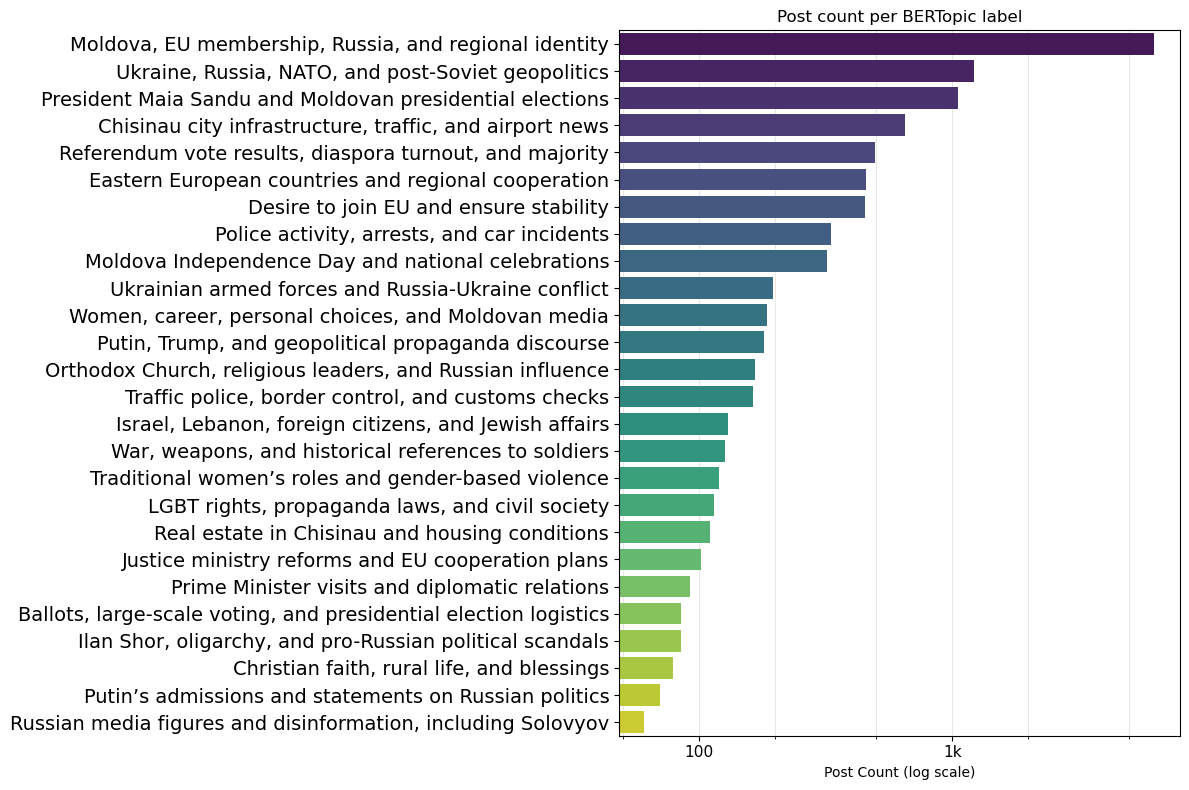

In [ ]:
value_counts = (
    moldova_df.loc[moldova_df['topic'].isin(ids), 'CustomName']
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 8))
plt.grid(axis='x', which='both', alpha=0.3)
plt.gca().set_axisbelow(True)

sns.barplot(
    x=value_counts.values,
    y=value_counts.index,
    palette="viridis"
)

plt.xscale('log')

ax = plt.gca()
ax.xaxis.set_major_locator(LogLocator(base=10))

def human_format(x, pos):
    if x >= 1_000_000:
        return f"{int(x/1_000_000)}M"
    elif x >= 1_000:
        return f"{int(x/1_000)}k"
    else:
        return f"{int(x)}"

ax.xaxis.set_major_formatter(FuncFormatter(human_format))


ax.tick_params(
    axis='y',
    labelsize=14 
)

ax.tick_params(
    axis='x',
    labelsize=11
)

plt.title(
    "Post count per BERTopic label",
    fontsize=20,      
    pad=12            
)


plt.subplots_adjust(left=0.35)  

plt.xlabel("Post Count (log scale)")
plt.ylabel("")
plt.title("Post count per BERTopic label")

plt.tight_layout()
plt.show()

## Topics distribution per platform

In [ ]:
moldova_df["language_group"] = moldova_df["language"].apply(
    lambda x: x if x in ["English", "Romanian", "Russian"] else "Other"
)

reddit = moldova_df[moldova_df['mediaType'] == 'Reddit']
facebook = moldova_df[moldova_df['mediaType'] == 'Facebook']
twitter = moldova_df[moldova_df['mediaType'] == 'Twitter']

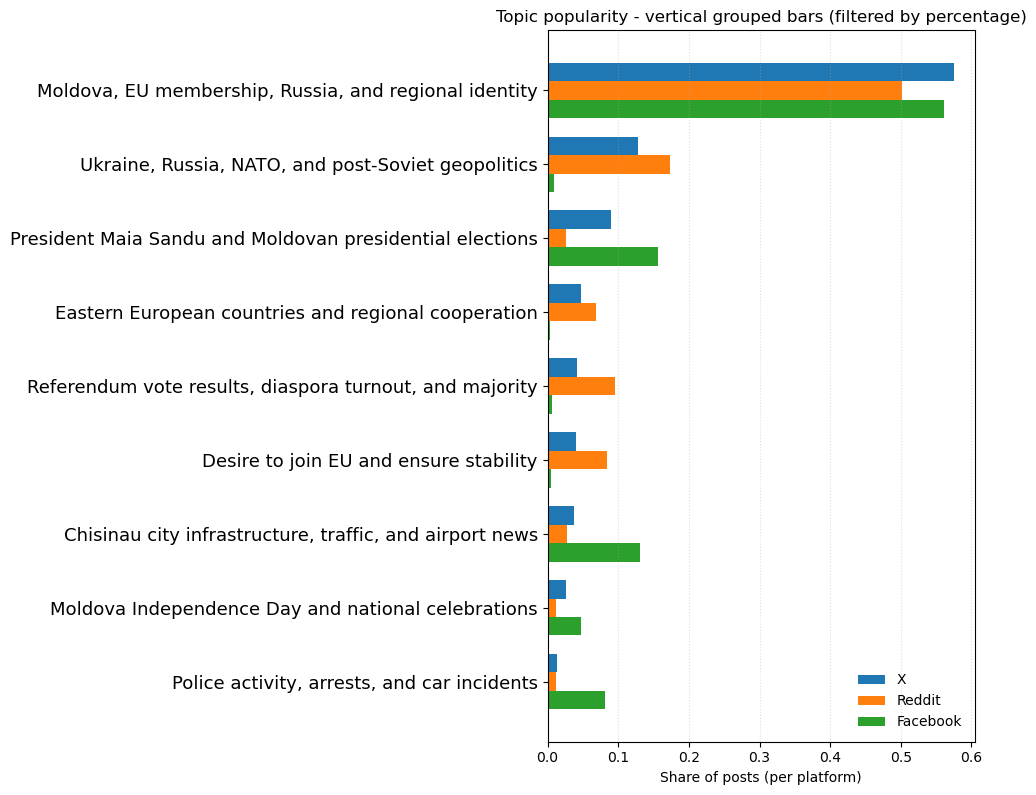

In [ ]:
def count_topics(df, ids, topic_col="CustomName", filter_col="topic"):
    return (df.loc[df[filter_col].isin(ids), topic_col]
              .value_counts().sort_values(ascending=False))

def plot_grouped_bars_vertical(
    A, B, C, ids,
    labels=("X","Reddit","Facebook"),
    topic_col="CustomName", filter_col="topic",
    min_pct=0.01,               
    min_present=1,             
    order_by="A",
    top_n=None,
    normalize=None,
    use_log=False
):
    # Counts per platform
    vcA = count_topics(A, ids, topic_col, filter_col)
    vcB = count_topics(B, ids, topic_col, filter_col)
    vcC = count_topics(C, ids, topic_col, filter_col)

    topics = sorted(set(vcA.index) | set(vcB.index) | set(vcC.index))
    df = pd.DataFrame({
        labels[0]: pd.Series(vcA, index=topics),
        labels[1]: pd.Series(vcB, index=topics),
        labels[2]: pd.Series(vcC, index=topics),
    }).fillna(0).astype(float)

    grand_total = df.values.sum()

    df["__share__"] = df.sum(axis=1) / grand_total

    presence = (df[[labels[0], labels[1], labels[2]]] > 0).sum(axis=1)
    keep = (df["__share__"] >= min_pct) & (presence >= min_present)

    df = df.loc[keep].drop(columns="__share__")

    if df.empty:
        print("No topics left after filtering. Try lowering min_pct or min_present.")
        return

    if normalize == "platform":
        df = df.div(df.sum(axis=0).replace(0, np.nan), axis=1).fillna(0)
        axis_label = "Share of posts (per platform)"
    elif normalize == "topic":
        df = df.div(df.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
        axis_label = "Share within topic"
    else:
        axis_label = "Post count"

    if order_by == "A":
        df = df.sort_values(by=labels[0], ascending=True)
    elif order_by == "B":
        df = df.sort_values(by=labels[1], ascending=True)
    elif order_by == "C":
        df = df.sort_values(by=labels[2], ascending=True)
    elif order_by == "total":
        df = df.assign(_t=df.sum(axis=1)).sort_values("_t", ascending=False).drop(columns="_t")

    if top_n:
        df = df.head(top_n)

    topics_kept = df.index.tolist()
    y = np.arange(len(topics_kept))
    w = 0.25

    fig, ax = plt.subplots(figsize=(10, 0.45*len(topics_kept) + 4))

    ax.barh(y + w, df[labels[0]].values, height=w, label=labels[0])
    ax.barh(y,      df[labels[1]].values, height=w, label=labels[1])
    ax.barh(y - w, df[labels[2]].values, height=w, label=labels[2])

    ax.set_yticks(y)
    ax.set_yticklabels(topics_kept)
    ax.set_xlabel(axis_label)
    plt.yticks(fontsize=13) 
    ax.set_title("Topic popularity - vertical grouped bars (filtered by percentage)")
    ax.grid(axis="x", linestyle=":", alpha=0.4)
    ax.legend(frameon=False, ncol=1, loc="lower right")

    if use_log and normalize is None:
        ax.set_xscale("log")
        ax.xaxis.set_major_formatter(ScalarFormatter())

    plt.tight_layout()
    plt.show()

plot_grouped_bars_vertical(
    twitter, reddit, facebook, ids,
    min_pct=0.02,         # keep topics ≥2% of all posts
    min_present=1,        
    order_by="A",         
    normalize="platform"
)

## Macro-topic distribution per language

In [ ]:
# Map topics to macro-topic groups
macro_topic_map = {
    4: "Geopolitics & EU Integration",
    6: "Geopolitics & EU Integration",
    7: "Geopolitics & EU Integration",
    12: "Geopolitics & EU Integration",
    20: "Geopolitics & EU Integration",
    30: "Geopolitics & EU Integration",
    33: "Geopolitics & EU Integration",
    35: "Geopolitics & EU Integration",

    0: "Domestic Politics & Governance",
    1: "Domestic Politics & Governance",
    25: "Domestic Politics & Governance",
    28: "Domestic Politics & Governance",
    34: "Domestic Politics & Governance",

    3: "Society & Civic Life",
    10: "Society & Civic Life",
    11: "Society & Civic Life",
    13: "Society & Civic Life",
    19: "Society & Civic Life",
    21: "Society & Civic Life",
    27: "Society & Civic Life",
    31: "Society & Civic Life",

    16: "Culture, Religion, & Conflict",
    18: "Culture, Religion, & Conflict",
    22: "Culture, Religion, & Conflict",
    29: "Culture, Religion, & Conflict",
    32: "Culture, Religion, & Conflict",
}

MACRO_ORDER = [
    "Geopolitics & EU Integration",
    "Domestic Politics & Governance",
    "Society & Civic Life",
    "Culture, Religion, & Conflict",
]

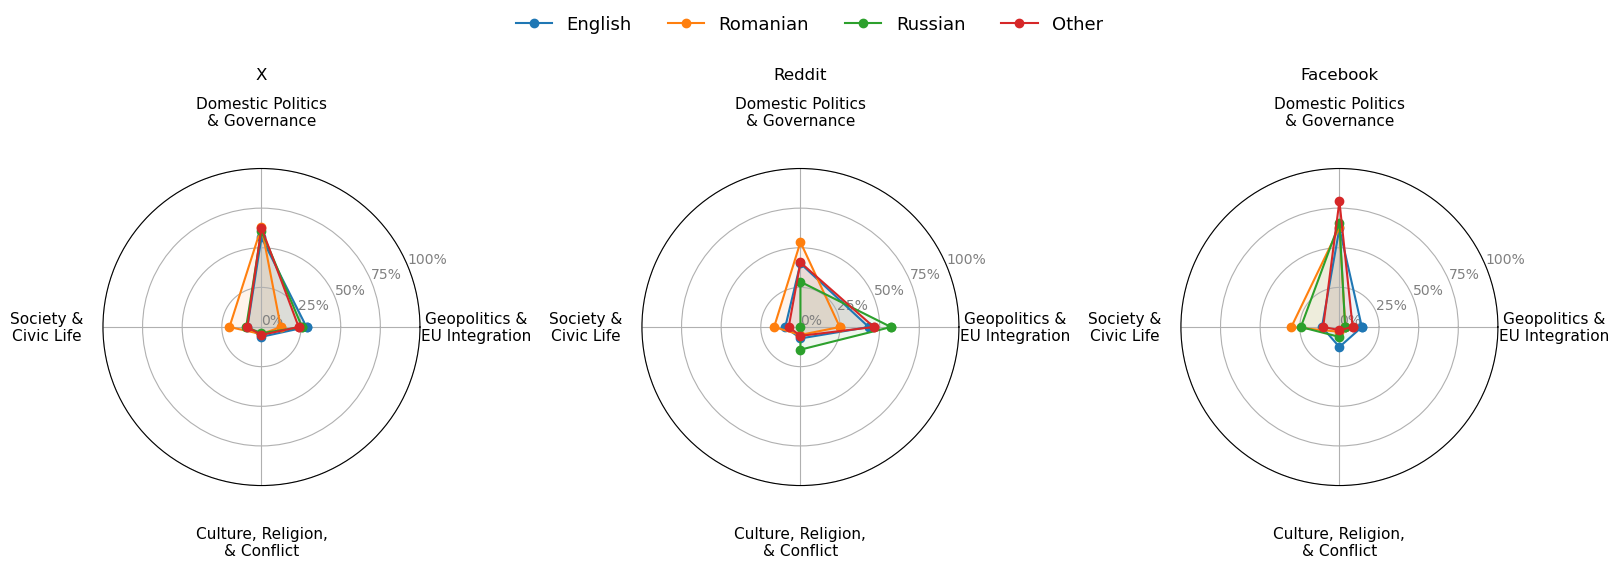

In [ ]:
def make_ct(df, macro_map, macro_order=None, language_order=None):
    df = df.copy()
    df["macro_topic"] = df["topic"].map(macro_map)
    df = df.dropna(subset=["macro_topic", "language_group"])

    ct = pd.crosstab(df["language_group"], df["macro_topic"])

    macros = macro_order or MACRO_ORDER
    langs = language_order or list(ct.index)

    ct = ct.reindex(index=langs, columns=macros, fill_value=0)

    # Normalize so each language sums to 1 across macro-topics
    ct = ct.div(ct.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
    return ct

def plot_radar_panel(ax, ct, title):
    macros = list(ct.columns)
    angles = np.linspace(0, 2*np.pi, len(macros), endpoint=False)
    angles_closed = np.concatenate([angles, angles[:1]])

    # Plot each language
    for lang in ct.index:
        vals = ct.loc[lang, macros].to_numpy()
        vals = np.concatenate([vals, vals[:1]])
        ax.plot(angles_closed, vals, marker="o", label=lang)
        ax.fill(angles_closed, vals, alpha=0.08)

    ax.set_xticks(angles)
    ax.set_xticklabels(macros, fontsize=11)

    ax.tick_params(axis="x", pad=30)

    wrap = {
    "Geopolitics & EU Integration": "Geopolitics &\nEU Integration",
    "Domestic Politics & Governance": "Domestic Politics\n& Governance",
    "Society & Civic Life": "Society &\nCivic Life",
    "Culture, Religion, & Conflict": "Culture, Religion,\n& Conflict",
    }
    ax.set_xticklabels([wrap.get(m, m) for m in macros], fontsize=11)    
    ax.set_yticks(np.linspace(0, 1, 5))
    ax.set_yticklabels([f"{int(t*100)}%" for t in np.linspace(0, 1, 5)], color="gray")
    ax.set_ylim(0, 1)

    ax.set_title(title, pad=12)


def three_radar(dfa, dfb, dfc, labels, macro_map, language_order=None):
    def langs(df):
        return df["language_group"].dropna().unique().tolist()

    union_langs = language_order or sorted(
        set(langs(dfa)) | set(langs(dfb)) | set(langs(dfc))
    )

    ct_a = make_ct(dfa, macro_map, MACRO_ORDER, union_langs)
    ct_b = make_ct(dfb, macro_map, MACRO_ORDER, union_langs)
    ct_c = make_ct(dfc, macro_map, MACRO_ORDER, union_langs)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw=dict(polar=True))

    plot_radar_panel(axes[0], ct_a, labels[0])
    plot_radar_panel(axes[1], ct_b, labels[1])
    plot_radar_panel(axes[2], ct_c, labels[2])

    handles, leg_labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, leg_labels, loc="upper center",
               ncol=4, frameon=False, fontsize=13)

    fig.subplots_adjust(top=0.80, wspace=0.70)  # instead of tight_layout()
    plt.show()

three_radar(twitter, reddit, facebook,
            labels=("X", "Reddit", "Facebook"),
            macro_map=macro_topic_map,
            language_order=["English", "Romanian", "Russian", "Other"]) 
